# MEI generation — val/test-ensemble protocol

Extends `mei_ensemble_atfirstsight.ipynb` with **three disjoint model ensembles**:

| ensemble | role | seeds (default) |
|----------|------|-----------------|
| **MEI**  | drives gradient ascent (objective ensemble) | 42, 43, 44 |
| **VAL**  | held-out signal for early stopping          | 52, 53     |
| **TEST** | unbiased final activation report            | 62         |

**Per neuron**:
1. Gradient ascent on MEI-ensemble mean activation (Walker et al. 2019: Fourier preconditioning, linear σ decay, pixel clamp, frozen pupil_center / behavior).
2. After every step, evaluate val-ensemble mean activation — keep a running *best-val snapshot*.
3. If val activation hasn't improved for `patience` steps, stop early and return the best-val snapshot (not the final image).
4. Report the test-ensemble mean activation on that snapshot — the unbiased number.

Train the val/test models first by re-running `1a_model_training_atfirstsight.ipynb` with `seed=52, 53, 62, …` and saving as `mcgill_model_mouse2_seed{S}_behavior0_eyepos1_gridmean1_shifter1.pth`. The cells below assume that naming.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys; sys.excepthook = sys.__excepthook__   # suppress datajoint's hook
import pathlib

import numpy as np
import torch
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from nnfabrik.builder import get_data, get_model
from sensorium.utility.scores import get_correlations

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {device}')

device: cuda


## 1. Configure the three ensembles

All members across all three ensembles must share the same `dataset_config` (so neuron count and input shape match). `model_config` may differ per checkpoint — each entry is a `(ckpt_path, model_config)` tuple.

The defaults below use seeds 42/43/44 (MEI), 52/53 (val), 62 (test). Update the lists once you've trained more seeds.

In [ ]:
DATA_PATH = '../../../data/mcgill/processed/dat_matrices-EC_EB_40_first_sight_animal_processed'
DATA_KEY  = '0-0-0'

dataset_config = {
    'paths': [DATA_PATH],
    'normalize': True,
    'include_behavior': False,
    'add_behavior_as_channels': True,   # ignored when include_behavior=False
    'include_eye_position': True,
    'batch_size': 128,
    'scale': 0.25,
}

grid_mean_predictor = {
    'type': 'cortex',
    'input_dimensions': 2,
    'hidden_layers': 1,
    'hidden_features': 30,
    'final_tanh': True,
}

model_config = {
    'pad_input': False,
    # core
    'stack': -1, 'layers': 4, 'input_kern': 9,
    'gamma_input': 6.3831, 'gamma_readout': 0.0076,
    'hidden_kern': 7, 'hidden_channels': 64,
    'depth_separable': True,
    # readout
    'grid_mean_predictor': grid_mean_predictor,
    'init_sigma': 0.1, 'init_mu_range': 0.3,
    'gauss_type': 'full', 'shifter': True,
    # modulator (off here)
    'modulator': False,
    'modulator_input_channels': 13,
    'modulator_hidden_channels': 10,
    'modulator_layers': 2,
}

CKPT_TEMPLATE = '../../../model_checkpoints/mcgill_model_mouse2_seed{seed}_behavior0_eyepos1_gridmean1_shifter1.pth'

MEI_SEEDS  = [42, 43, 44]
VAL_SEEDS  = [52, 53]      # bump to [52, 53, 54] once trained
TEST_SEEDS = [62]          # bump to [62, 63, 64] once trained

def ckpts_for(seeds):
    return [(CKPT_TEMPLATE.format(seed=s), model_config) for s in seeds]

CHECKPOINTS_MEI  = ckpts_for(MEI_SEEDS)
CHECKPOINTS_VAL  = ckpts_for(VAL_SEEDS)
CHECKPOINTS_TEST = ckpts_for(TEST_SEEDS)

for label, lst in [('MEI', CHECKPOINTS_MEI), ('VAL', CHECKPOINTS_VAL), ('TEST', CHECKPOINTS_TEST)]:
    print(f'{label}: {len(lst)} model(s)')
    for p, _ in lst:
        present = '\u2713' if pathlib.Path(p).is_file() else '\u2717 MISSING'
        print(f'  {present}  {p}')

## 2. Load dataloaders and instantiate all ensembles

In [3]:
dataloaders = get_data('sensorium.datasets.static_loaders', dataset_config)
input_shape = tuple(dataloaders['train'][DATA_KEY].dataset[0][0].shape)    # (C, H, W)
print(f'per-trial input shape: {input_shape}')

def load_model(ckpt_path, model_config, dataloaders, seed=42):
    m = get_model('sensorium.models.stacked_core_full_gauss_readout',
                  model_config, dataloaders=dataloaders, seed=seed)
    m.load_state_dict(torch.load(ckpt_path, map_location=device))
    m.to(device).eval()
    return m

def load_ensemble(checkpoints, base_seed):
    return [load_model(p, cfg, dataloaders, seed=base_seed + i)
            for i, (p, cfg) in enumerate(checkpoints)]

ensemble_mei  = load_ensemble(CHECKPOINTS_MEI,  base_seed=42)
ensemble_val  = load_ensemble(CHECKPOINTS_VAL,  base_seed=52)
ensemble_test = load_ensemble(CHECKPOINTS_TEST, base_seed=62)
print(f'sizes: MEI={len(ensemble_mei)}  VAL={len(ensemble_val)}  TEST={len(ensemble_test)}')

per-trial input shape: (1, 36, 64)
sizes: MEI=3  VAL=2  TEST=1


## 3. Rank neurons by MEI-ensemble test correlation

We pick the neurons to optimize using the **MEI ensemble**'s test-tier correlation (same convention as `mei_ensemble_atfirstsight.ipynb`). The val/test ensembles are reserved for stopping criterion / unbiased eval — they don't drive selection.

In [4]:
per_model_corr = [get_correlations(m, dataloaders, tier='test', device=device, as_dict=False, per_neuron=True)
                  for m in ensemble_mei]
mei_corr = np.mean(per_model_corr, axis=0)            # (n_neurons,)
ranked_neurons = np.argsort(mei_corr)[::-1]

print(f'n_neurons: {len(mei_corr)}')
print(f'top-5 ρ (MEI ensemble): {mei_corr[ranked_neurons[:5]].round(3)}  (neurons {ranked_neurons[:5]})')
print(f'median ρ: {np.median(mei_corr):.3f}')

n_neurons: 730
top-5 ρ (MEI ensemble): [0.753 0.735 0.719 0.7   0.692]  (neurons [345 187 116 371  19])
median ρ: 0.244


## 4. Training-set means for `pupil_center` / `behavior`

Same convention as Walker et al. 2019: freeze the non-stimulus inputs to their training-set mean, so the gradient ascent only optimizes the image.

In [5]:
def training_mean(dataloaders, key, data_key=DATA_KEY):
    acc, n = 0.0, 0
    for batch in dataloaders['train'][data_key]:
        if not hasattr(batch, key):
            return None
        b = getattr(batch, key).float()
        acc = acc + b.sum(0)
        n  += b.shape[0]
    return (acc / n).unsqueeze(0).to(device)

mean_pupil    = training_mean(dataloaders, 'pupil_center')
mean_behavior = training_mean(dataloaders, 'behavior')

print(f'mean pupil_center (z-scored): {mean_pupil.cpu().numpy().round(4)}')
if mean_behavior is not None:
    print(f'mean behavior[:5] (z-scored): {mean_behavior.cpu().numpy()[0,:5].round(4)}')
else:
    print('no behavior in this dataloader')

mean pupil_center (z-scored): [[-0.0048  0.0128]]
no behavior in this dataloader


## 5. MEI generator with val-driven early stopping

What changes vs. the plain ensemble version:

- A single forward+backward through the **MEI ensemble** drives the gradient.
- After each step we forward (no-grad) through the **val** and **test** ensembles to log their mean activations.
- We track the *best-val* image across the trajectory, **excluding the first `warmup` steps**. The random-Gaussian init produces a small lucky activation that — for neurons whose val/MEI optima disagree — never gets beaten, locking the early-stop trigger to a noise image. Skipping the first `warmup=50` steps avoids that.
- Stop when val activation hasn't improved for `patience` steps after warmup. Return the best-val snapshot — not the final image.

Walker's σ-blur schedule is kept (linear decay over `n_steps`); if early stopping fires before σ reaches its floor, the returned MEI is slightly blurrier than the Walker baseline. That is the intended behavior — further sharpening past val plateau is by definition optimization-ensemble overfit.

In [6]:
def fourier_lowpass(h, w, alpha=0.1, device='cuda'):
    fy = torch.fft.fftfreq(h, device=device)
    fx = torch.fft.fftfreq(w, device=device)
    Fx, Fy = torch.meshgrid(fx, fy, indexing='xy')
    freq_sq = Fx**2 + Fy**2
    freq_sq[0, 0] = 1.0
    filt = (1.0 / (2 * np.pi)**2) * freq_sq.pow(-alpha)
    return filt / filt[0, 0]


def ensemble_mean_activation(models, x, neuron_idx, data_key, pupil_center, behavior=None):
    acts = [m(x, data_key=data_key, pupil_center=pupil_center, behavior=behavior)[0, neuron_idx]
            for m in models]
    return torch.stack(acts).mean()


def generate_mei_valtest(
    mei_models, val_models, test_models,
    data_key, neuron_idx, input_shape,
    pupil_center, mean_behavior=None,
    n_steps=1000, lr=1.0,
    blur_sigma_start=1.5, blur_sigma_end=0.1,
    precond_alpha=0.1, clamp_range=(-2.5, 2.5),
    patience=150, warmup=50,
    seed=42, device='cuda', verbose=False,
):
    """Walker-style gradient ascent driven by `mei_models`, with early stopping on
    `val_models` mean activation. `test_models` is logged but never drives anything.

    Returns `(best_img_np, info)` where `info` has the per-step traces and stop step.
    """
    C, H, W = input_shape
    n_behavior_ch = C - 1   # > 0 only when add_behavior_as_channels=True

    if n_behavior_ch > 0:
        assert mean_behavior is not None, \
            f'model expects {C} channels ({n_behavior_ch} behavior) but mean_behavior is None'
        beh_ch = mean_behavior.view(1, n_behavior_ch, 1, 1).expand(1, n_behavior_ch, H, W).to(device)
        behavior_kw = None   # behavior is in the image tensor
    else:
        beh_ch = None
        behavior_kw = mean_behavior if mean_behavior is not None else None

    torch.manual_seed(seed); np.random.seed(seed)
    img = torch.randn(1, 1, H, W, device=device) * 0.1
    img.requires_grad_(True)

    lowpass     = fourier_lowpass(H, W, alpha=precond_alpha, device=device)
    blur_sigmas = np.linspace(blur_sigma_start, blur_sigma_end, n_steps)

    best_val_act = -float('inf')
    best_step = warmup     # fallback if patience never fires; updated as soon as we exit warmup
    best_img  = img.detach().clone()
    plateau   = 0
    stopped_at = n_steps

    mei_trace, val_trace, test_trace = [], [], []

    iterator = tqdm(range(n_steps), desc=f'neuron {neuron_idx}', leave=False) if verbose else range(n_steps)
    for step in iterator:
        if img.grad is not None: img.grad.zero_()
        x = torch.cat([img, beh_ch], dim=1) if beh_ch is not None else img

        # MEI ensemble — drives the gradient
        mei_act = ensemble_mean_activation(mei_models, x, neuron_idx, data_key, pupil_center, behavior_kw)
        mei_act.backward()
        mei_trace.append(float(mei_act.item()))

        # Val + test ensembles — observation only
        with torch.no_grad():
            val_act  = float(ensemble_mean_activation(val_models,  x, neuron_idx, data_key, pupil_center, behavior_kw).item())
            test_act = float(ensemble_mean_activation(test_models, x, neuron_idx, data_key, pupil_center, behavior_kw).item())
        val_trace.append(val_act)
        test_trace.append(test_act)

        # Update best-val snapshot — but only past warmup (random-init spike must not lock the trigger)
        if step >= warmup:
            if val_act > best_val_act:
                best_val_act = val_act
                best_step = step
                best_img  = img.detach().clone()
                plateau = 0
            else:
                plateau += 1

        # Ascent step + Walker post-processing
        with torch.no_grad():
            grad = img.grad[0, 0]
            grad = torch.fft.ifft2(torch.fft.fft2(grad) * lowpass).real
            img.data[0, 0] += lr * grad
            sigma = float(blur_sigmas[step])
            if sigma > 0.05:
                k = max(3, int(2 * round(3 * sigma) + 1))
                img.data = TF.gaussian_blur(img.data, kernel_size=[k, k], sigma=[sigma, sigma])
            img.data.clamp_(*clamp_range)
        img.requires_grad_(True)

        # Early stopping — patience counts only past warmup
        if step >= warmup and plateau >= patience:
            stopped_at = step + 1
            break

    info = {
        'mei_trace':  np.asarray(mei_trace,  dtype=np.float32),
        'val_trace':  np.asarray(val_trace,  dtype=np.float32),
        'test_trace': np.asarray(test_trace, dtype=np.float32),
        'best_step':  int(best_step),
        'stopped_at': int(stopped_at),
        'best_val_act':  float(best_val_act),
        'best_test_act': float(test_trace[best_step]),
        'best_mei_act':  float(mei_trace[best_step]),
    }
    return best_img.detach()[0, 0].cpu().numpy(), info

## 6. Generate MEIs for the top-K neurons

In [7]:
N_TO_GENERATE = 64         # 8×8 grid
N_STEPS       = 1000
PATIENCE      = 150
WARMUP        = 50         # skip best-val tracking + patience counting for the first N steps
                           # — the random-Gaussian init produces a small lucky spike on val for some
                           # neurons that would otherwise lock the trigger to a noise image

top_ids   = ranked_neurons[:N_TO_GENERATE]
top_corrs = mei_corr[top_ids]

meis, infos = {}, {}
for nid in tqdm(top_ids, desc='neurons'):
    mei, info = generate_mei_valtest(
        ensemble_mei, ensemble_val, ensemble_test,
        DATA_KEY, int(nid), input_shape,
        pupil_center=mean_pupil, mean_behavior=mean_behavior,
        n_steps=N_STEPS, lr=1.0,
        patience=PATIENCE, warmup=WARMUP,
        seed=42, device=device,
    )
    meis[int(nid)]  = mei
    infos[int(nid)] = info

stop_steps = np.array([infos[int(i)]['stopped_at'] for i in top_ids])
best_steps = np.array([infos[int(i)]['best_step']  for i in top_ids])
print(f'stopped_at — median {int(np.median(stop_steps))}, range [{stop_steps.min()}, {stop_steps.max()}]')
print(f'best_step  — median {int(np.median(best_steps))}, range [{best_steps.min()}, {best_steps.max()}]')

out_dir = pathlib.Path('../figures/mei/mcgill_mouse2/behavior0_eyepos1_gridmean1_shifter1')
out_dir.mkdir(parents=True, exist_ok=True)

# Pack traces with their lengths so reload is unambiguous (early-stopped → shorter).
save_kwargs = {f'neuron_{k}': v for k, v in meis.items()}
for k, info in infos.items():
    save_kwargs[f'neuron_{k}__mei_trace']  = info['mei_trace']
    save_kwargs[f'neuron_{k}__val_trace']  = info['val_trace']
    save_kwargs[f'neuron_{k}__test_trace'] = info['test_trace']
np.savez(
    out_dir / 'meis_valtest_ensemble.npz',
    __ranked_ids=np.array(top_ids),
    __corrs=top_corrs,
    __best_steps=best_steps,
    __stopped_at=stop_steps,
    __best_val_act=np.array([infos[int(i)]['best_val_act']  for i in top_ids], dtype=np.float32),
    __best_test_act=np.array([infos[int(i)]['best_test_act'] for i in top_ids], dtype=np.float32),
    __best_mei_act=np.array([infos[int(i)]['best_mei_act']  for i in top_ids], dtype=np.float32),
    **save_kwargs,
)
print(f'saved {len(meis)} MEIs → {out_dir / "meis_valtest_ensemble.npz"}')

neurons:   0%|          | 0/64 [00:00<?, ?it/s]

stopped_at — median 1000, range [518, 1000]
best_step  — median 886, range [367, 999]
saved 64 MEIs → ../figures/mei/mcgill_mouse2/behavior0_eyepos1_gridmean1_shifter1/meis_valtest_ensemble.npz


## 7. Trace diagnostics

For a handful of neurons, plot the per-step activation in each ensemble alongside the val-best snapshot and the early-stop point. Useful to see *whether* val and test track each other or diverge.

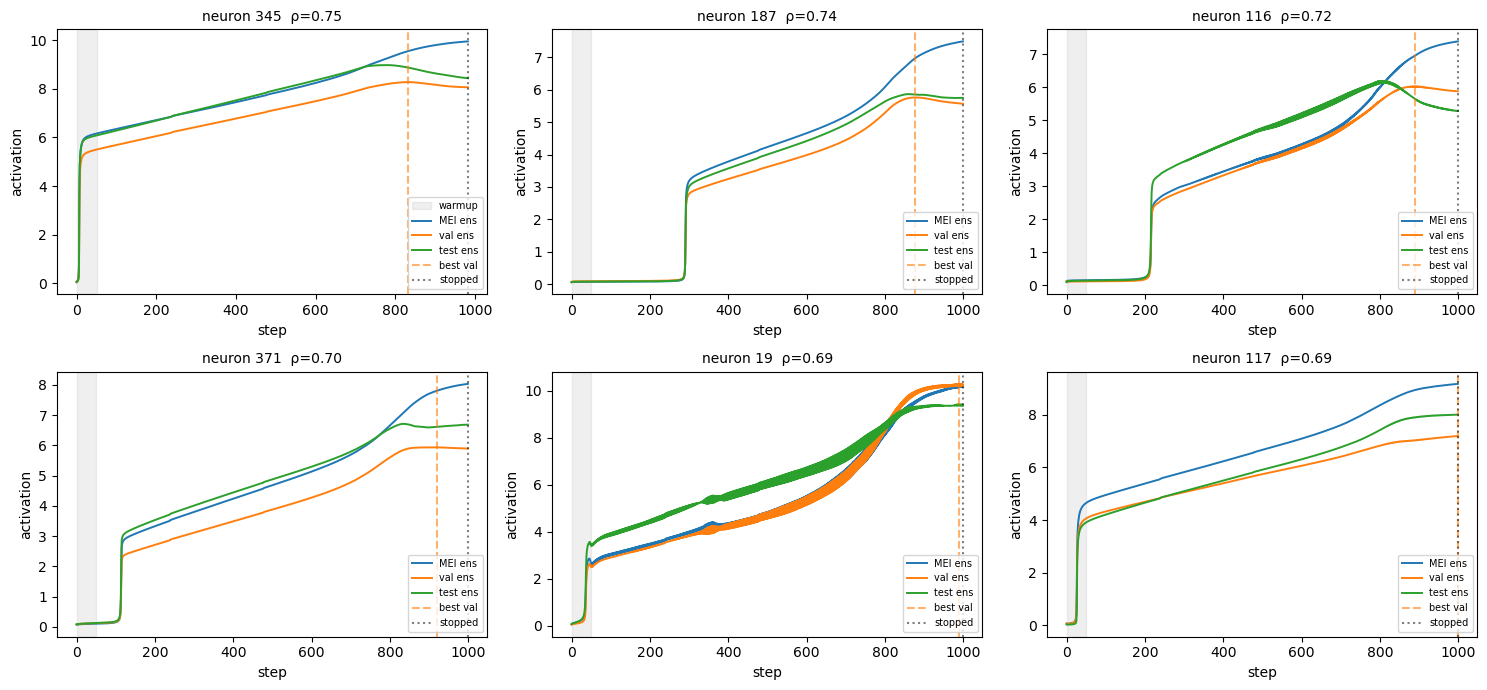

In [8]:
N_TRACES = 6
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=False)
axes = axes.ravel()
for ax, nid in zip(axes, top_ids[:N_TRACES]):
    info = infos[int(nid)]
    steps = np.arange(len(info['mei_trace']))
    ax.axvspan(0, WARMUP, color='gray', alpha=0.12, label='warmup' if ax is axes[0] else None)
    ax.plot(steps, info['mei_trace'],  label='MEI ens',  color='C0', lw=1.4)
    ax.plot(steps, info['val_trace'],  label='val ens',  color='C1', lw=1.4)
    ax.plot(steps, info['test_trace'], label='test ens', color='C2', lw=1.4)
    ax.axvline(info['best_step'],  color='C1', ls='--', alpha=0.6, label='best val')
    ax.axvline(info['stopped_at'], color='k',  ls=':',  alpha=0.5, label='stopped')
    ax.set_title(f'neuron {int(nid)}  ρ={mei_corr[int(nid)]:.2f}', fontsize=10)
    ax.set_xlabel('step'); ax.set_ylabel('activation')
    ax.legend(fontsize=7, loc='lower right')
plt.tight_layout()
plt.savefig(out_dir / 'mei_valtest_traces.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 8×8 grid of MEIs (val-selected snapshots)

Same display normalization as `mei_ensemble_atfirstsight.ipynb` — per-MEI median subtraction, shared P99 colormap range. Titles show MEI-ensemble ρ + the unbiased test-ensemble activation.

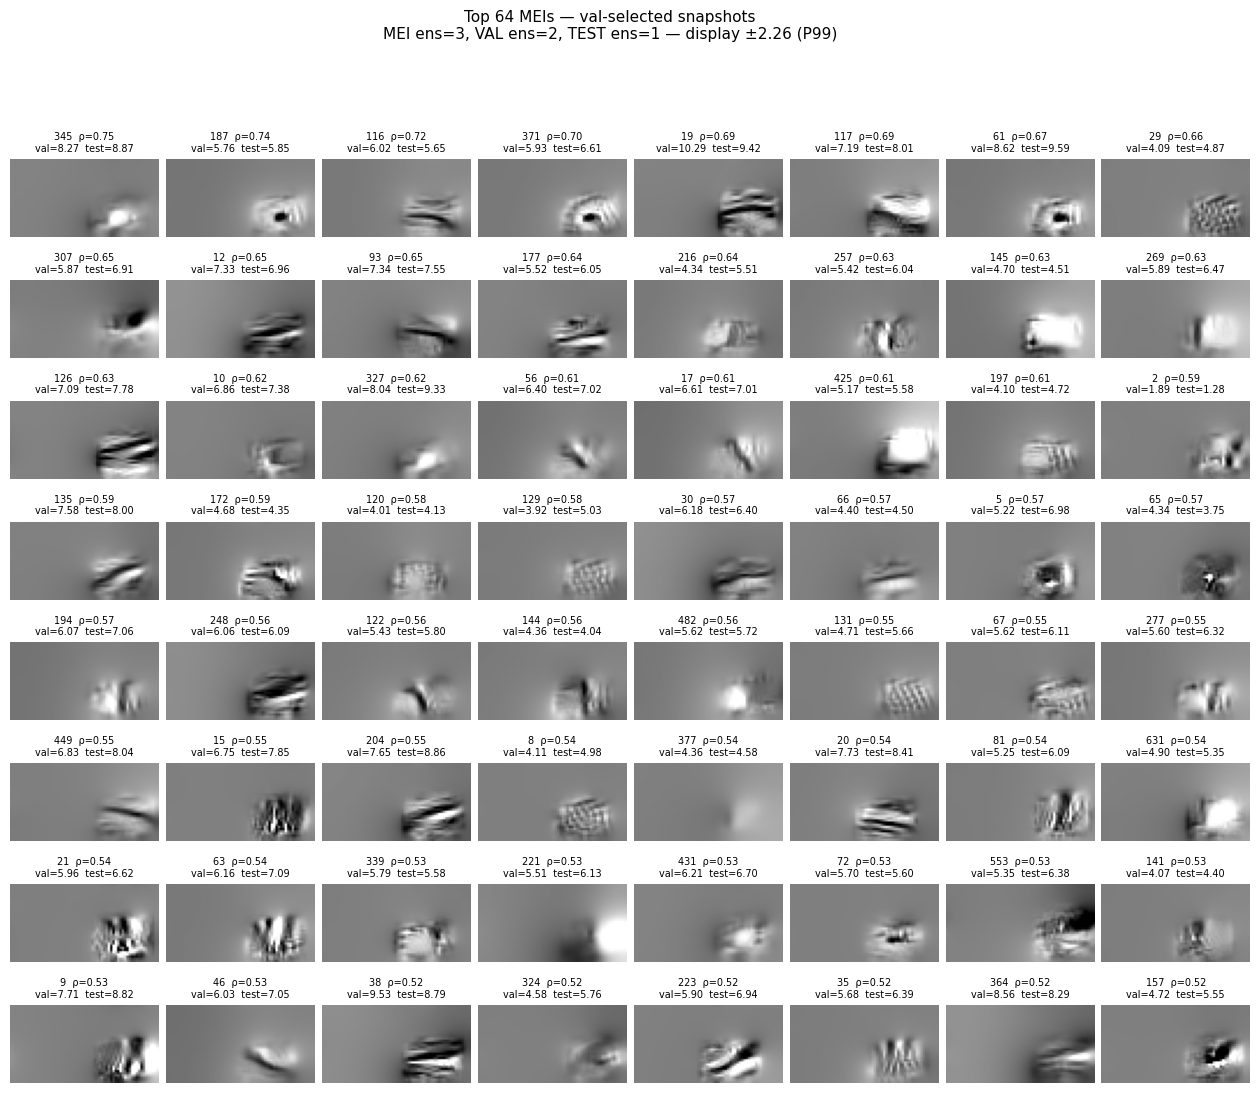

In [9]:
GRID_ROWS, GRID_COLS = 8, 8
assert GRID_ROWS * GRID_COLS <= len(meis), 'not enough MEIs for grid'

ordered_ids = list(top_ids[:GRID_ROWS * GRID_COLS])

normalized = np.stack([meis[int(i)] - np.median(meis[int(i)]) for i in ordered_ids])
vmax = np.percentile(np.abs(normalized), 99); vmin = -vmax

fig, axes = plt.subplots(GRID_ROWS, GRID_COLS,
                         figsize=(GRID_COLS * 2.0, GRID_ROWS * 1.5),
                         gridspec_kw=dict(hspace=0.55, wspace=0.05))
for k, nid in enumerate(ordered_ids):
    r, c = divmod(k, GRID_COLS); ax = axes[r, c]
    ax.imshow(normalized[k], cmap='gray', vmin=vmin, vmax=vmax, aspect='auto')
    info = infos[int(nid)]
    ax.set_title(f'{int(nid)}  ρ={mei_corr[int(nid)]:.2f}\n'
                 f'val={info["best_val_act"]:.2f}  test={info["best_test_act"]:.2f}',
                 fontsize=7)
    ax.axis('off')
plt.suptitle(f'Top {GRID_ROWS * GRID_COLS} MEIs — val-selected snapshots\n'
             f'MEI ens={len(ensemble_mei)}, VAL ens={len(ensemble_val)}, TEST ens={len(ensemble_test)} '
             f'— display ±{vmax:.2f} (P99)', fontsize=11, y=1.005)
plt.tight_layout()
plt.savefig(out_dir / 'mei_valtest_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Specificity matrix on the **test ensemble**

Walker et al. 2019 Fig. 2b, but evaluated on the held-out test ensemble (the MEI ensemble would inflate the diagonal — that's the activation we maximized). A diagonal that still dominates the columns means the MEIs generalize across model seeds.

In [ ]:
def compute_mei_responses(models, meis_dict, ordered_ids, input_shape, data_key,
                          pupil_center, mean_behavior=None, device='cuda'):
    for m in models: m.eval()
    C, H, W = input_shape
    if C > 1:
        beh_ch = mean_behavior.view(1, C-1, 1, 1).expand(1, C-1, H, W).to(device)
        behavior_kw = None
    else:
        beh_ch = None
        behavior_kw = mean_behavior if mean_behavior is not None else None

    responses = []
    with torch.no_grad():
        for nid in ordered_ids:
            img = torch.from_numpy(meis_dict[int(nid)]).float().view(1, 1, H, W).to(device)
            x   = torch.cat([img, beh_ch], dim=1) if beh_ch is not None else img
            out = torch.stack([m(x, data_key=data_key, pupil_center=pupil_center, behavior=behavior_kw)[0]
                               for m in models]).mean(0)
            responses.append(out.cpu().numpy())
    return np.stack(responses)


R_test = compute_mei_responses(ensemble_test, meis, ordered_ids, input_shape, DATA_KEY,
                               mean_pupil, mean_behavior, device=device)
sub_test = R_test[:, ordered_ids]
col_max  = sub_test.max(axis=0, keepdims=True); col_max[col_max == 0] = 1
sub_norm = sub_test / col_max

n    = sub_test.shape[0]
diag = np.diag(sub_test)
off  = np.array([np.concatenate([sub_test[:i, i], sub_test[i+1:, i]]).mean() for i in range(n)])
si   = diag / np.maximum(off, 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
im = axes[0].imshow(sub_norm, cmap='hot', aspect='auto')
axes[0].set_xlabel('neuron index (in ranked order)')
axes[0].set_ylabel('MEI index (in ranked order)')
axes[0].set_title(f'Specificity on TEST ensemble (col-normalized, n={n})')
plt.colorbar(im, ax=axes[0], shrink=0.8)

axes[1].hist(si, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(np.median(si), color='red', ls='--', label=f'median = {np.median(si):.2f}')
axes[1].set_xlabel('selectivity (own / mean others)')
axes[1].set_ylabel('# neurons')
axes[1].set_title('Selectivity index (test-ensemble)')
axes[1].legend()
plt.tight_layout()
plt.savefig(out_dir / 'mei_valtest_specificity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'TEST-ensemble selectivity: mean={si.mean():.2f}, median={np.median(si):.2f}')

## 10. Cross-ensemble activation comparison

For each MEI, plot its own-neuron activation as measured by the three ensembles. Healthy outcome: val and test activations are close to each other and a fair fraction of the MEI activation — large gaps signal that gradient ascent is exploiting the MEI ensemble's idiosyncrasies.

In [ ]:
best_mei  = np.array([infos[int(i)]['best_mei_act']  for i in ordered_ids])
best_val  = np.array([infos[int(i)]['best_val_act']  for i in ordered_ids])
best_test = np.array([infos[int(i)]['best_test_act'] for i in ordered_ids])

idx = np.arange(len(ordered_ids))
w   = 0.28

fig, ax = plt.subplots(figsize=(max(8, 0.18 * len(ordered_ids)), 4))
ax.bar(idx - w, best_mei,  w, label=f'MEI ens (n={len(ensemble_mei)})',  color='C0')
ax.bar(idx,     best_val,  w, label=f'val ens (n={len(ensemble_val)})',  color='C1')
ax.bar(idx + w, best_test, w, label=f'test ens (n={len(ensemble_test)})', color='C2')
ax.set_xlabel('MEI index (descending MEI-ens ρ)')
ax.set_ylabel('activation at val-best step')
ax.set_title('Cross-ensemble activation — should track if MEIs generalize')
ax.legend()
ax.set_xticks(idx[::4])
plt.tight_layout()
plt.savefig(out_dir / 'mei_valtest_activation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

ratio_val  = best_val  / np.maximum(best_mei, 1e-8)
ratio_test = best_test / np.maximum(best_mei, 1e-8)
print(f'val/mei  ratio — median {np.median(ratio_val):.2f}')
print(f'test/mei ratio — median {np.median(ratio_test):.2f}')